In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
df = pd.read_csv("movie-data/movies_encoded.csv")

In [3]:
#print(df.columns.tolist())

'id', 'title', 'vote_average', 'vote_count', 'release_date', 'release_year', 'release_month', 'revenue', 'runtime', 'budget', 'popularity', 
 
 'actor_avg', 'actor_med', 'actor_dev', 'production_avg', 'production_med', 'production_dev', 
 
 
 'original_title_matches', 'adult_False', 'adult_True', 
 
 'orig_lang_ab', 'orig_lang_af', 'orig_lang_am', 'orig_lang_ar', 'orig_lang_az', 'orig_lang_be', 'orig_lang_bg', 'orig_lang_bm', 
 'orig_lang_bn', 'orig_lang_bs', 'orig_lang_ca', 
 'orig_lang_cn', 'orig_lang_cs', 'orig_lang_cy', 'orig_lang_da', 'orig_lang_de', 'orig_lang_dv', 'orig_lang_dz', 'orig_lang_el', 
 'orig_lang_en', 'orig_lang_es', 'orig_lang_et', 'orig_lang_eu', 'orig_lang_fa', 'orig_lang_fi', 'orig_lang_fr', 'orig_lang_ga', 
 'orig_lang_gl', 'orig_lang_gu', 'orig_lang_he', 'orig_lang_hi', 'orig_lang_hr', 'orig_lang_hu', 'orig_lang_hy', 'orig_lang_id', 
 'orig_lang_is', 'orig_lang_it', 'orig_lang_iu', 'orig_lang_ja', 'orig_lang_ka', 'orig_lang_km', 'orig_lang_kn', 'orig_lang_ko', 
 'orig_lang_ku', 'orig_lang_la', 'orig_lang_lg', 'orig_lang_lt', 'orig_lang_lv', 'orig_lang_mi', 'orig_lang_mk', 'orig_lang_ml', 
 'orig_lang_mn', 'orig_lang_mr', 'orig_lang_ms', 'orig_lang_my', 'orig_lang_nb', 'orig_lang_ne', 'orig_lang_nl', 'orig_lang_no', 
 'orig_lang_pa', 'orig_lang_pl', 'orig_lang_pt', 'orig_lang_ro', 'orig_lang_ru', 'orig_lang_rw', 'orig_lang_si', 'orig_lang_sk', 
 'orig_lang_sl', 'orig_lang_sr', 'orig_lang_sv', 'orig_lang_sw', 'orig_lang_ta', 'orig_lang_te', 'orig_lang_tg', 'orig_lang_th', 
 'orig_lang_tl', 'orig_lang_tn', 'orig_lang_tr', 'orig_lang_uk', 'orig_lang_ur', 'orig_lang_uz', 'orig_lang_vi', 'orig_lang_xh', 
 'orig_lang_xx', 'orig_lang_zh', 'orig_lang_zu', 
 
 'Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 
 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western', 

 'Afghanistan', 'Algeria', 'Andorra', 'Angola', 'Argentina', 'Armenia', 'Aruba', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 
 'Bahrain', 'Bangladesh', 'Belarus', 'Belgium', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Bulgaria', 
 'Burkina Faso', 'Cambodia', 'Cameroon', 'Canada', 'Chile', 'China', 'Colombia', 'Congo', 'Cook Islands', "Cote D'Ivoire", 'Croatia',
 'Cuba', 'Cyprus', 'Czech Republic', 'Czechoslovakia', 'Denmark', 'Dominican Republic', 'East Germany', 'Ecuador', 'Egypt', 'Estonia', 
 'Ethiopia', 'Fiji', 'Finland', 'France', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Guadaloupe', 'Guatemala', 'Honduras', 'Hong Kong', 
 'Hungary', 'Iceland', 'India', 'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Jordan', 'Kazakhstan',
 'Kenya', 'Kuwait', 'Latvia', 'Lebanon', 'Libyan Arab Jamahiriya', 'Liechtenstein', 'Lithuania', 'Luxembourg', 'Macao', 'Macedonia', 
 'Malaysia', 'Maldives', 'Mali', 'Malta', 'Marshall Islands', 'Mauritania', 'Mauritius', 'Mexico', 'Monaco', 'Mongolia', 'Montenegro', 
 'Morocco', 'Mozambique', 'Myanmar', 'Namibia', 'Nepal', 'Netherlands', 'Netherlands Antilles', 'New Zealand', 'Nicaragua', 'Nigeria',
 'North Korea', 'Norway', 'Pakistan', 'Palestinian Territory', 'Paraguay', 'Peru', 'Philippines', 'Poland', 'Portugal', 
 'Puerto Rico', 'Qatar', 'Romania', 'Russia', 'Rwanda', 'Saudi Arabia', 'Senegal', 'Serbia', 'Singapore', 'Slovakia', 'Slovenia',
 'Solomon Islands', 'South Africa', 'South Korea', 'Soviet Union', 'Spain', 'Sri Lanka', 'Sweden', 'Switzerland', 
 'Syrian Arab Republic', 'Taiwan', 'Tajikistan', 'Tanzania', 'Thailand', 'Tunisia', 'Turkey', 'Uganda', 'Ukraine', 
 'United Arab Emirates', 'United Kingdom', 'United States of America', 'Uruguay', 'Venezuela', 'Vietnam', 'Yemen', 
 'Yugoslavia', 'Zimbabwe', 
 
 'Abkhazian', 'Afrikaans', 'Akan', 'Albanian', 'Amharic', 'Arabic', 'Armenian', 'Avaric',
 'Azerbaijani', 'Bambara', 'Basque', 'Belarusian', 'Bengali', 'Bosnian', 'Breton', 'Bulgarian', 'Burmese', 'Cantonese', 'Catalan', 
 'Chechen', 'Chichewa; Nyanja', 'Cornish', 'Corsican', 'Cree', 'Croatian', 'Czech', 'Danish', 'Divehi', 'Dutch', 'Dzongkha', 'English', 
 'Esperanto', 'Estonian', 'Faroese', 'Fijian', 'Finnish', 'French', 'Fulah', 'Gaelic', 'Galician', 'Ganda', 'Georgian', 'German', 'Greek', 
 'Guarani', 'Gujarati', 'Haitian; Haitian Creole', 'Hausa', 'Hebrew', 'Hindi', 'Hiri Motu', 'Hungarian', 'Icelandic', 'Ido', 'Indonesian', 
 'Inuktitut', 'Irish', 'Italian', 'Japanese', 'Javanese', 'Kannada', 'Kashmiri', 'Kazakh', 'Khmer', 'Kinyarwanda', 'Korean', 'Kurdish', 
 'Lao', 'Latin', 'Latvian', 'Letzeburgesch', 'Lingala', 'Lithuanian', 'Macedonian', 'Malay', 'Malayalam', 'Maltese', 'Mandarin', 'Maori',
 'Marathi', 'Marshall', 'Moldavian', 'Mongolian', 'Navajo', 'Nepali', 'No Language', 'Northern Sami', 'Norwegian', 'Norwegian Bokmål', 
 'Persian', 'Polish', 'Portuguese', 'Punjabi', 'Pushto', 'Quechua', 'Romanian', 'Rundi', 'Russian', 'Samoan', 'Sanskrit', 'Sardinian', 
 'Serbian', 'Serbo-Croatian', 'Shona', 'Sindhi', 'Sinhalese', 'Slovak', 'Slovenian', 'Somali', 'Sotho', 'Spanish', 'Sundanese', 'Swahili', 
 'Swedish', 'Tagalog', 'Tahitian', 'Tajik', 'Tamil', 'Tatar', 'Telugu', 'Thai', 'Tibetan', 'Tonga', 'Tswana', 'Turkish', 'Uighur', 'Ukrainian', 
 'Urdu', 'Vietnamese', 'Volapük', 'Welsh', 'Wolof', 'Xhosa', 'Yiddish', 'Yoruba', 'Zulu'

In [4]:
# Profit column.
# This will set profit to NaN when budget is 0.
# WHY????

# df['profit'] = np.where(df['budget'] == 0, np.nan, df['revenue'] - df['budget'])
df["profit"] = df["revenue"] - df["budget"]
print(df["profit"].describe())
print(df["profit"].isna().sum())


count    1.683200e+04
mean     2.844490e+07
std      1.042033e+08
min     -1.995460e+08
25%      1.800000e+02
50%      1.106328e+06
75%      1.420424e+07
max      2.686706e+09
Name: profit, dtype: float64
0


In [5]:
# Check for null values and duplicates
print(df.isna().sum()[df.isna().sum() > 0])
print("------------------------------------------")
print(df.duplicated().sum())

release_date      326
actor_avg         155
actor_med         155
actor_dev         155
production_avg    130
production_med    130
production_dev    130
dtype: int64
------------------------------------------
0


array([[<Axes: title={'center': 'profit'}>,
        <Axes: title={'center': 'revenue'}>,
        <Axes: title={'center': 'budget'}>],
       [<Axes: title={'center': 'release_year'}>,
        <Axes: title={'center': 'vote_count'}>,
        <Axes: title={'center': 'vote_average'}>],
       [<Axes: title={'center': 'actor_avg'}>,
        <Axes: title={'center': 'actor_med'}>,
        <Axes: title={'center': 'actor_dev'}>],
       [<Axes: title={'center': 'production_avg'}>,
        <Axes: title={'center': 'production_med'}>,
        <Axes: title={'center': 'production_dev'}>]], dtype=object)

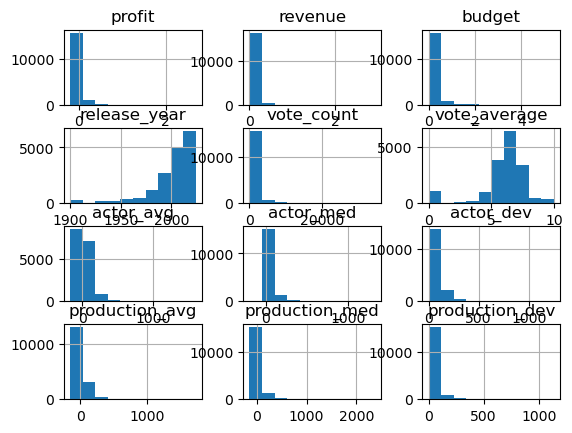

In [6]:
df.hist(column=["profit", "revenue", "budget", "release_year", "vote_count", "vote_average", "actor_avg", 'actor_med', 'actor_dev', 'production_avg', 'production_med', 'production_dev'])


In [7]:
pd.set_option('display.float_format', '{:,.2f}'.format)
df[["profit", "revenue", "budget", "release_year", "vote_count", "vote_average", "actor_avg", 'actor_med', 'actor_dev', 'production_avg', 'production_med', 'production_dev']].describe()

,profit,revenue,budget,release_year,vote_count,vote_average,actor_avg,actor_med,actor_dev,production_avg,production_med,production_dev
count,"16,832.00","16,832.00","16,832.00","16,832.00","16,832.00","16,832.00","16,677.00","16,677.00","16,677.00","16,702.00","16,702.00","16,702.00"
mean,"28,444,899.31","42,599,972.21","14,155,072.90","2,000.76",971.88,5.95,40.44,17.07,71.28,29.56,21.44,41.36
std,"104,203,321.85","125,726,133.61","31,815,870.01",22.84,"2,404.32",1.91,103.42,85.36,95.40,126.81,125.86,85.17
min,"-199,545,977.00",1.00,0.00,"1,900.00",0.00,0.00,-168.31,-197.33,0.00,-149.09,-149.09,0.00
25%,180.00,"302,000.00",0.00,"1,994.00",17.00,5.56,-22.99,-27.70,7.21,-24.68,-24.95,0.61
50%,"1,106,328.00","4,028,340.50","918,500.00","2,008.00",146.00,6.30,6.76,-17.65,45.09,-14.83,-20.10,9.53
75%,"14,204,241.00","26,712,653.75","14,000,000.00","2,015.00",747.00,7.00,65.35,31.00,98.33,30.63,15.33,45.23
max,"2,686,706,026.00","2,923,706,026.00","540,000,000.00","2,024.00","34,495.00",10.00,"1,599.34","1,318.47","1,250.25","1,733.11","2,370.75","1,136.62"


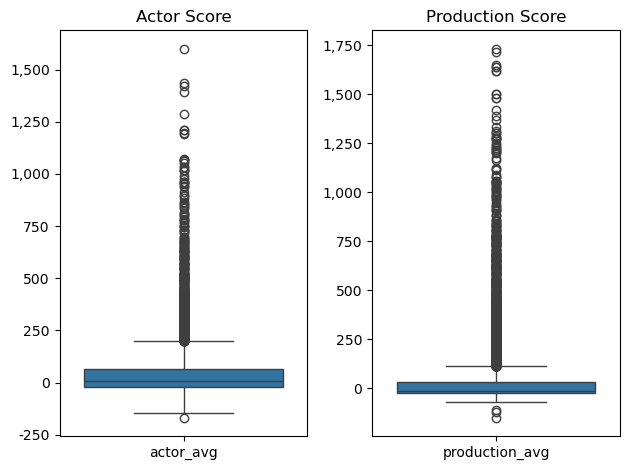

In [8]:
fig, axes = plt.subplots(1, 2)

sns.boxplot(data=df[['actor_avg']], ax=axes[0])
axes[0].set_title('Actor Score')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))  # Formats as whole numbers with commas

sns.boxplot(data=df[['production_avg']], ax=axes[1])
axes[1].set_title('Production Score')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))  # Formats as whole numbers with commas

plt.tight_layout()
plt.savefig("figures/actor and production score box and whiskers.png", bbox_inches = 'tight')
plt.show()

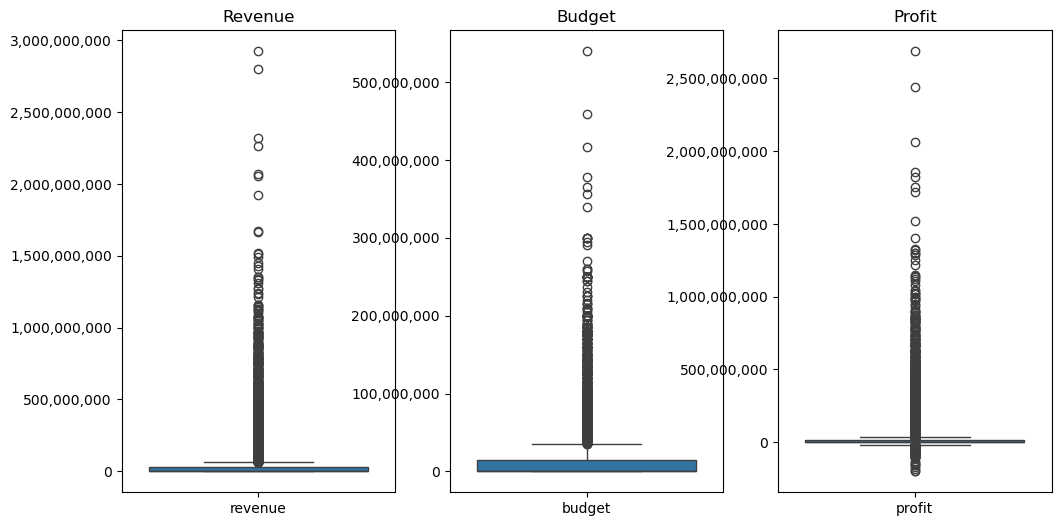

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

sns.boxplot(data=df[['revenue']], ax=axes[0])
axes[0].set_title('Revenue')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))  # Formats as whole numbers with commas

sns.boxplot(data=df[['budget']], ax=axes[1])
axes[1].set_title('Budget')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))  # Formats as whole numbers with commas

sns.boxplot(data=df[['profit']], ax=axes[2])
axes[2].set_title('Profit')
axes[2].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))  # Formats as whole numbers with commas

plt.savefig("figures/revenue budget and profit box and whiskers.png", bbox_inches = 'tight')
plt.show()

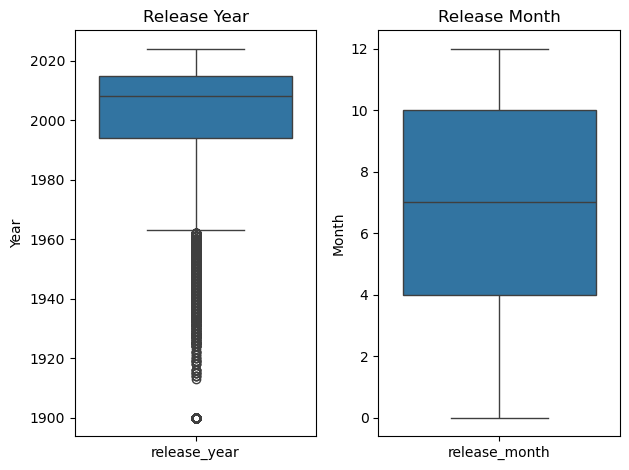

In [10]:
fig, axes = plt.subplots(1, 2)

sns.boxplot(data=df[['release_year']], ax=axes[0])
axes[0].set_title('Release Year')
axes[0].set_ylabel('Year')

sns.boxplot(data=df[['release_month']], ax=axes[1])
axes[1].set_title('Release Month')
axes[1].set_ylabel('Month')

plt.tight_layout()
plt.savefig("figures/release year and month box and whiskers.png", bbox_inches = 'tight')
plt.show()

In [11]:
prft = df[["profit", "revenue", "budget"]].copy()

prft.dropna(subset=["profit"], inplace=True)

print(prft.describe())

# these are different ways of calculating profitability. 0 is profitable and 1 is un-profitable
prft["basic_profitability"] = np.where(prft["budget"].isna(), np.nan, np.where(prft["profit"] > 0, 0, 1))

prft["profit_margin"] = prft["profit"] / prft["budget"]
prft["relative_profitability"] = np.where(prft["profit_margin"] > 0, 0, 1)

prft["ROI"] = (df['revenue'] - df['budget']) / df['budget']
prft["return_on_investment_profitability"] = np.where(prft["revenue"] >= prft["budget"], 0, 1)

# Turns out this isn't called break even, but I won't change it so I don't break anything.
# It's really just a 100% + returns threshold.
prft["break_even_profitability"] = np.where(prft["revenue"] >= (prft["budget"] * 2), 0, 1)

print(prft["basic_profitability"].value_counts())
print(prft["relative_profitability"].value_counts())
print(prft["return_on_investment_profitability"].value_counts())
print(prft["break_even_profitability"].value_counts())

# column for un-profitability where 1 is unprofitable and 0 is profitable.

                profit          revenue         budget
count        16,832.00        16,832.00      16,832.00
mean     28,444,899.31    42,599,972.21  14,155,072.90
std     104,203,321.85   125,726,133.61  31,815,870.01
min    -199,545,977.00             1.00           0.00
25%             180.00       302,000.00           0.00
50%       1,106,328.00     4,028,340.50     918,500.00
75%      14,204,241.00    26,712,653.75  14,000,000.00
max   2,686,706,026.00 2,923,706,026.00 540,000,000.00
basic_profitability
0.00    12978
1.00     3854
Name: count, dtype: int64
relative_profitability
0    12978
1     3854
Name: count, dtype: int64
return_on_investment_profitability
0    13377
1     3455
Name: count, dtype: int64
break_even_profitability
0    10948
1     5884
Name: count, dtype: int64


In [12]:
df["un_profitability"] = prft["break_even_profitability"]


In [13]:
genres = ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 
 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']

adult = ['adult_False', 'adult_True']

original_languages = ['orig_lang_ab', 'orig_lang_af', 'orig_lang_am', 'orig_lang_ar', 'orig_lang_az', 'orig_lang_be', 'orig_lang_bg', 'orig_lang_bm', 
 'orig_lang_bn', 'orig_lang_bs', 'orig_lang_ca', 'orig_lang_cn', 'orig_lang_cs', 'orig_lang_cy', 'orig_lang_da', 'orig_lang_de', 'orig_lang_dv', 'orig_lang_dz', 'orig_lang_el', 
 'orig_lang_en', 'orig_lang_es', 'orig_lang_et', 'orig_lang_eu', 'orig_lang_fa', 'orig_lang_fi', 'orig_lang_fr', 'orig_lang_ga', 
 'orig_lang_gl', 'orig_lang_gu', 'orig_lang_he', 'orig_lang_hi', 'orig_lang_hr', 'orig_lang_hu', 'orig_lang_hy', 'orig_lang_id', 
 'orig_lang_is', 'orig_lang_it', 'orig_lang_iu', 'orig_lang_ja', 'orig_lang_ka', 'orig_lang_km', 'orig_lang_kn', 'orig_lang_ko', 
 'orig_lang_ku', 'orig_lang_la', 'orig_lang_lg', 'orig_lang_lt', 'orig_lang_lv', 'orig_lang_mi', 'orig_lang_mk', 'orig_lang_ml', 
 'orig_lang_mn', 'orig_lang_mr', 'orig_lang_ms', 'orig_lang_my', 'orig_lang_nb', 'orig_lang_ne', 'orig_lang_nl', 'orig_lang_no', 
 'orig_lang_pa', 'orig_lang_pl', 'orig_lang_pt', 'orig_lang_ro', 'orig_lang_ru', 'orig_lang_rw', 'orig_lang_si', 'orig_lang_sk', 
 'orig_lang_sl', 'orig_lang_sr', 'orig_lang_sv', 'orig_lang_sw', 'orig_lang_ta', 'orig_lang_te', 'orig_lang_tg', 'orig_lang_th', 
 'orig_lang_tl', 'orig_lang_tn', 'orig_lang_tr', 'orig_lang_uk', 'orig_lang_ur', 'orig_lang_uz', 'orig_lang_vi', 'orig_lang_xh', 
 'orig_lang_xx', 'orig_lang_zh', 'orig_lang_zu']

countries = ['Afghanistan', 'Algeria', 'Andorra', 'Angola', 'Argentina', 'Armenia', 'Aruba', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 
 'Bahrain', 'Bangladesh', 'Belarus', 'Belgium', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Bulgaria', 
 'Burkina Faso', 'Cambodia', 'Cameroon', 'Canada', 'Chile', 'China', 'Colombia', 'Congo', 'Cook Islands', "Cote D'Ivoire", 'Croatia',
 'Cuba', 'Cyprus', 'Czech Republic', 'Czechoslovakia', 'Denmark', 'Dominican Republic', 'East Germany', 'Ecuador', 'Egypt', 'Estonia', 
 'Ethiopia', 'Fiji', 'Finland', 'France', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Guadaloupe', 'Guatemala', 'Honduras', 'Hong Kong', 
 'Hungary', 'Iceland', 'India', 'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Jordan', 'Kazakhstan',
 'Kenya', 'Kuwait', 'Latvia', 'Lebanon', 'Libyan Arab Jamahiriya', 'Liechtenstein', 'Lithuania', 'Luxembourg', 'Macao', 'Macedonia', 
 'Malaysia', 'Maldives', 'Mali', 'Malta', 'Marshall Islands', 'Mauritania', 'Mauritius', 'Mexico', 'Monaco', 'Mongolia', 'Montenegro', 
 'Morocco', 'Mozambique', 'Myanmar', 'Namibia', 'Nepal', 'Netherlands', 'Netherlands Antilles', 'New Zealand', 'Nicaragua', 'Nigeria',
 'North Korea', 'Norway', 'Pakistan', 'Palestinian Territory', 'Paraguay', 'Peru', 'Philippines', 'Poland', 'Portugal', 
 'Puerto Rico', 'Qatar', 'Romania', 'Russia', 'Rwanda', 'Saudi Arabia', 'Senegal', 'Serbia', 'Singapore', 'Slovakia', 'Slovenia',
 'Solomon Islands', 'South Africa', 'South Korea', 'Soviet Union', 'Spain', 'Sri Lanka', 'Sweden', 'Switzerland', 
 'Syrian Arab Republic', 'Taiwan', 'Tajikistan', 'Tanzania', 'Thailand', 'Tunisia', 'Turkey', 'Uganda', 'Ukraine', 
 'United Arab Emirates', 'United Kingdom', 'United States of America', 'Uruguay', 'Venezuela', 'Vietnam', 'Yemen', 
 'Yugoslavia', 'Zimbabwe']

languages = ['Abkhazian', 'Afrikaans', 'Akan', 'Albanian', 'Amharic', 'Arabic', 'Armenian', 'Avaric',
 'Azerbaijani', 'Bambara', 'Basque', 'Belarusian', 'Bengali', 'Bosnian', 'Breton', 'Bulgarian', 'Burmese', 'Cantonese', 'Catalan', 
 'Chechen', 'Chichewa; Nyanja', 'Cornish', 'Corsican', 'Cree', 'Croatian', 'Czech', 'Danish', 'Divehi', 'Dutch', 'Dzongkha', 'English', 
 'Esperanto', 'Estonian', 'Faroese', 'Fijian', 'Finnish', 'French', 'Fulah', 'Gaelic', 'Galician', 'Ganda', 'Georgian', 'German', 'Greek', 
 'Guarani', 'Gujarati', 'Haitian; Haitian Creole', 'Hausa', 'Hebrew', 'Hindi', 'Hiri Motu', 'Hungarian', 'Icelandic', 'Ido', 'Indonesian', 
 'Inuktitut', 'Irish', 'Italian', 'Japanese', 'Javanese', 'Kannada', 'Kashmiri', 'Kazakh', 'Khmer', 'Kinyarwanda', 'Korean', 'Kurdish', 
 'Lao', 'Latin', 'Latvian', 'Letzeburgesch', 'Lingala', 'Lithuanian', 'Macedonian', 'Malay', 'Malayalam', 'Maltese', 'Mandarin', 'Maori',
 'Marathi', 'Marshall', 'Moldavian', 'Mongolian', 'Navajo', 'Nepali', 'No Language', 'Northern Sami', 'Norwegian', 'Norwegian Bokmål', 
 'Persian', 'Polish', 'Portuguese', 'Punjabi', 'Pushto', 'Quechua', 'Romanian', 'Rundi', 'Russian', 'Samoan', 'Sanskrit', 'Sardinian', 
 'Serbian', 'Serbo-Croatian', 'Shona', 'Sindhi', 'Sinhalese', 'Slovak', 'Slovenian', 'Somali', 'Sotho', 'Spanish', 'Sundanese', 'Swahili', 
 'Swedish', 'Tagalog', 'Tahitian', 'Tajik', 'Tamil', 'Tatar', 'Telugu', 'Thai', 'Tibetan', 'Tonga', 'Tswana', 'Turkish', 'Uighur', 'Ukrainian', 
 'Urdu', 'Vietnamese', 'Volapük', 'Welsh', 'Wolof', 'Xhosa', 'Yiddish', 'Yoruba', 'Zulu']


In [14]:
original_title_counts = df[["original_title_matches"]].sum()
print(original_title_counts)
print("-------------------------------------------------")

genre_counts = df[genres].sum().sort_values(ascending=False)
print(genre_counts)
print("-------------------------------------------------")

adult_counts = df[adult].sum().sort_values(ascending=False)
print(adult_counts)
print("-------------------------------------------------")

org_lang_counts = df[original_languages].sum().sort_values(ascending=False)
print(org_lang_counts)
print("-------------------------------------------------")

country_counts = df[countries].sum().sort_values(ascending=False)
print(country_counts)
print("-------------------------------------------------")

language_counts = df[languages].sum().sort_values(ascending=False)
print(language_counts)

original_title_matches    12428
dtype: int64
-------------------------------------------------
Drama              7844
Comedy             5717
Action             3406
Thriller           3386
Romance            2991
Adventure          2191
Crime              2112
Horror             1785
Family             1500
Fantasy            1319
Science Fiction    1309
Mystery            1190
Animation          1020
History             760
Documentary         685
Music               636
War                 525
Western             227
TV Movie             47
dtype: int64
-------------------------------------------------
adult_False    16786
adult_True        46
dtype: int64
-------------------------------------------------
orig_lang_en    11150
orig_lang_es      669
orig_lang_fr      632
orig_lang_ja      469
orig_lang_hi      422
                ...  
orig_lang_lv        1
orig_lang_mi        1
orig_lang_mn        1
orig_lang_my        1
orig_lang_zu        1
Length: 86, dtype: int64
--------------

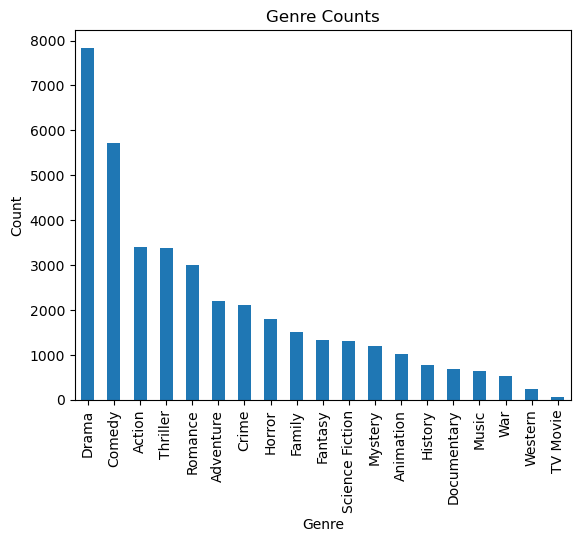

In [15]:
ax = genre_counts.plot(kind="bar")
ax.set_title("Genre Counts")
ax.set_ylabel("Count")
ax.set_xlabel("Genre")
plt.savefig("figures/genre counts.png", bbox_inches = 'tight')



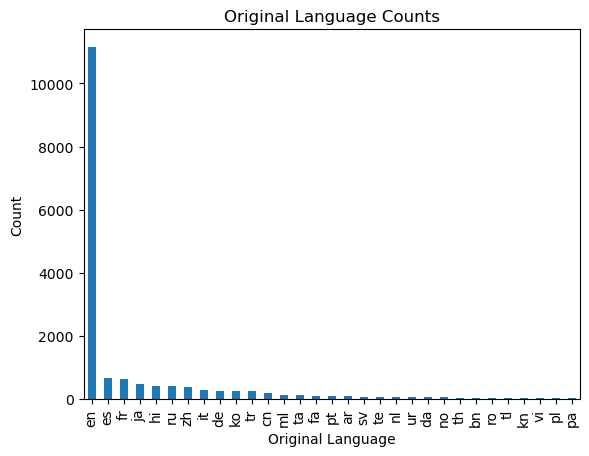

In [16]:
# Filtering for only values greater than 20.
ax = org_lang_counts[org_lang_counts > 20].plot(kind="bar")
ax.set_title("Original Language Counts")
ax.set_ylabel("Count")
ax.set_xlabel("Original Language")

labels = [item.get_text() for item in ax.get_xticklabels()]

remove_text = lambda x: str(x)[10:]

for i in range(len(labels)):
    labels[i] = remove_text(labels[i])

ax.set_xticklabels(labels)

plt.savefig("figures/original language counts.png", bbox_inches = 'tight')

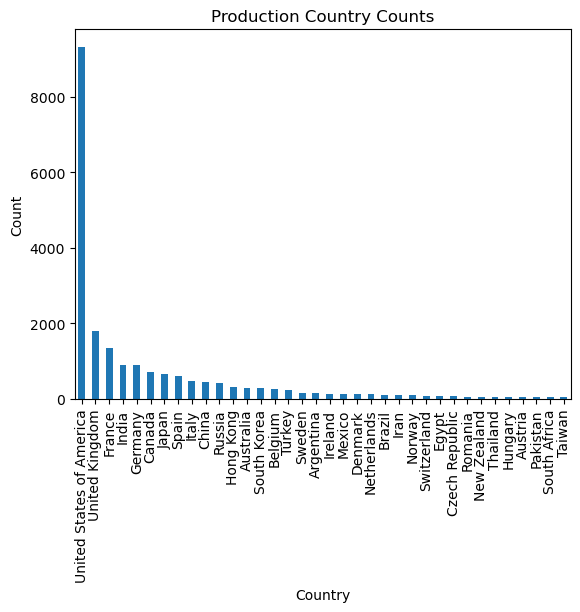

In [17]:
# Filtering for only values greater than 50.
ax = country_counts[country_counts > 50].plot(kind="bar")
ax.set_title("Production Country Counts")
ax.set_ylabel("Count")
ax.set_xlabel("Country")
plt.savefig("figures/production country.png", bbox_inches = 'tight')

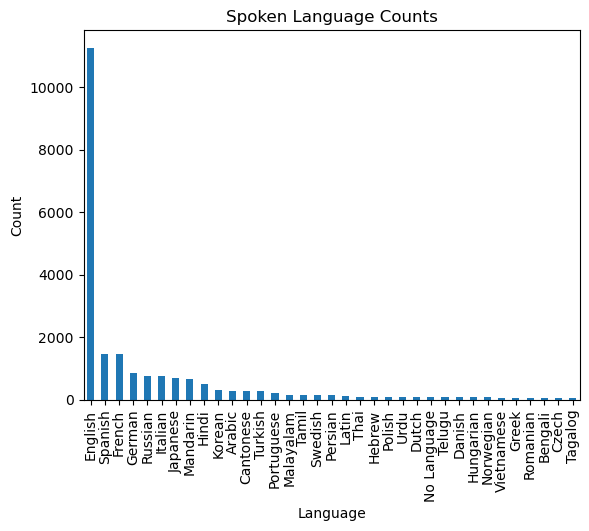

In [18]:
# Filtering for only values greater than 50.
ax = language_counts[language_counts > 50].plot(kind="bar")
ax.set_title("Spoken Language Counts")
ax.set_ylabel("Count")
ax.set_xlabel("Language")
plt.savefig("figures/spoken language counts.png", bbox_inches = 'tight')

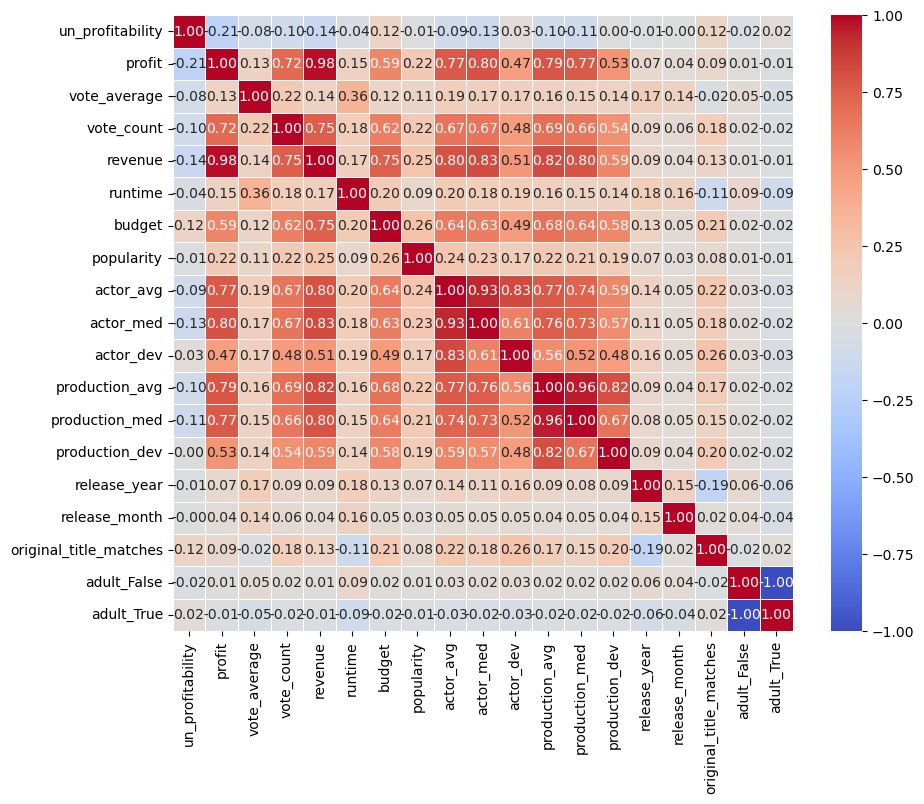

In [19]:
basic_columns = ["un_profitability", "profit", 'vote_average', 'vote_count', 'revenue', 'runtime', 'budget', 'popularity', 'actor_avg', 
             'actor_med', 'actor_dev', 'production_avg', 'production_med', 'production_dev', 'release_year',
             'release_month', 'original_title_matches', 'adult_False', 'adult_True']

correlation = df[basic_columns].corr()
# print(correlation)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.savefig("figures/heatmap of features.png", bbox_inches = 'tight')
plt.show()

In [20]:
# You can use this as a basic list of columns to do correlations with.
basic_columns = ["un_profitability", "profit", "revenue", "budget", "release_year", "release_month", "runtime", 'vote_average', 
                 'vote_count', 'popularity', 'actor_avg', 'actor_med', 'actor_dev', 'production_avg', 
                 'production_med', 'production_dev']

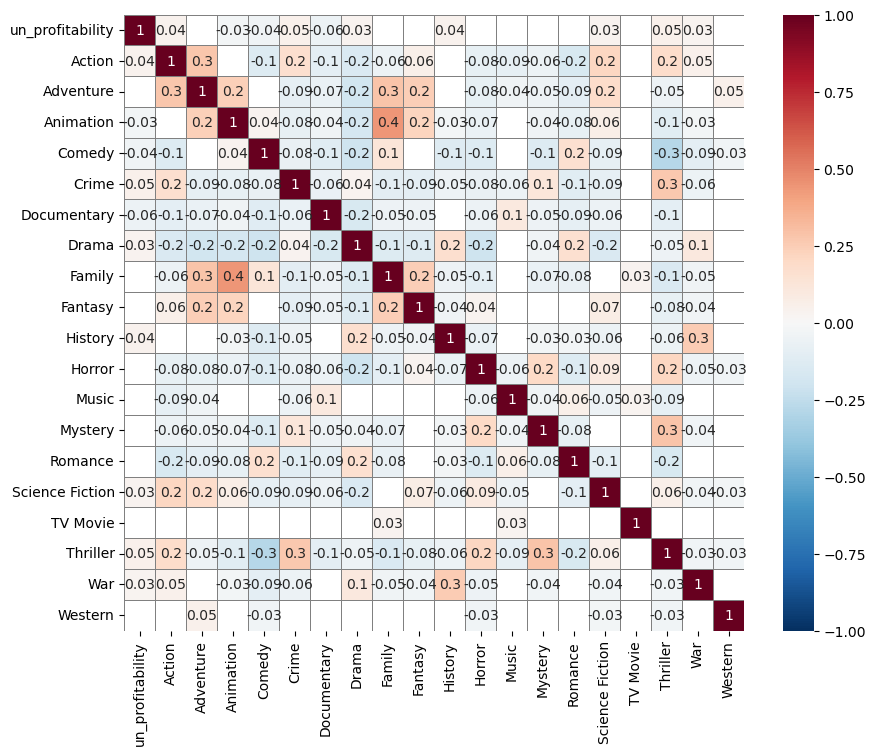

In [21]:
added_genres = ["un_profitability"] + genres
genres_correlation = df[added_genres].corr()

# Filtering out the correlations less than or equal to [filter] to make the heatmap easier to read.
filter = 0.025
filtered_corr = genres_correlation[(genres_correlation > filter) | (genres_correlation < -filter)].dropna(how='all', axis=0).dropna(how='all', axis=1)

plt.figure(figsize=(10, 8))
sns.heatmap(
    filtered_corr,
    annot=True,
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    fmt=".1g", 
    linewidths=0.5, linecolor="grey")
plt.savefig("figures/heatmap of genre.png", bbox_inches = 'tight')
plt.show()

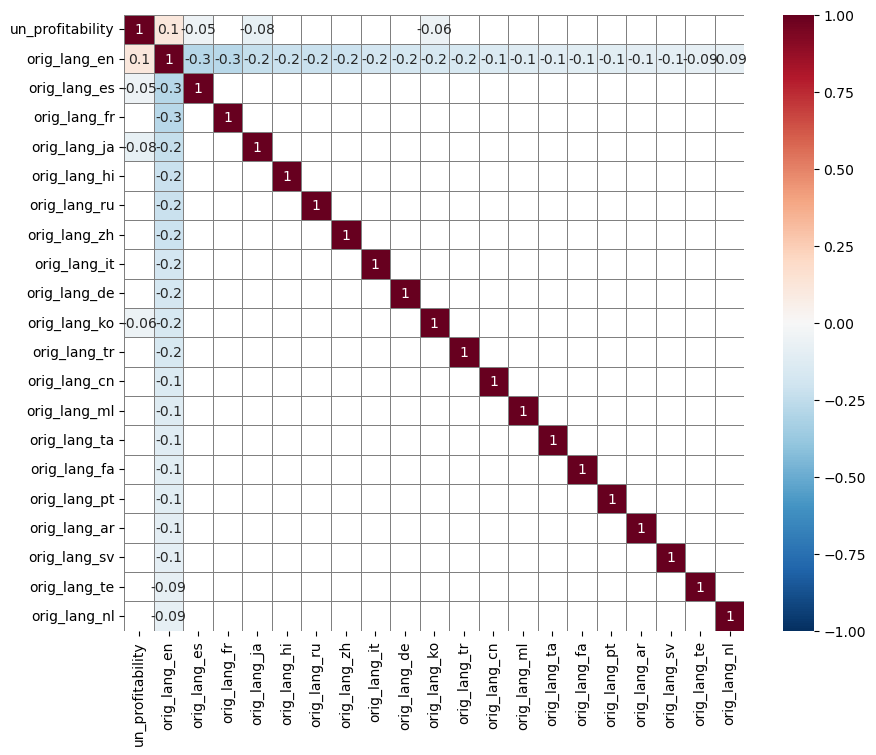

In [22]:
# only takes the top 20 common original languages.
added_org_lang = ["un_profitability"] + org_lang_counts.head(20).index.tolist()
org_lang_correlation = df[added_org_lang].corr()

# Filtering out the correlations less than or equal to [filter] to make the heatmap easier to read.
filter = 0.05
filtered_corr = org_lang_correlation[(org_lang_correlation > filter) | (org_lang_correlation < -filter)].dropna(how='all', axis=0).dropna(how='all', axis=1)

plt.figure(figsize=(10, 8))
sns.heatmap(
    filtered_corr,
    annot=True,
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    fmt=".1g", 
    linewidths=0.5, linecolor="grey")
plt.savefig("figures/heatmap of original language.png", bbox_inches = 'tight')
plt.show()

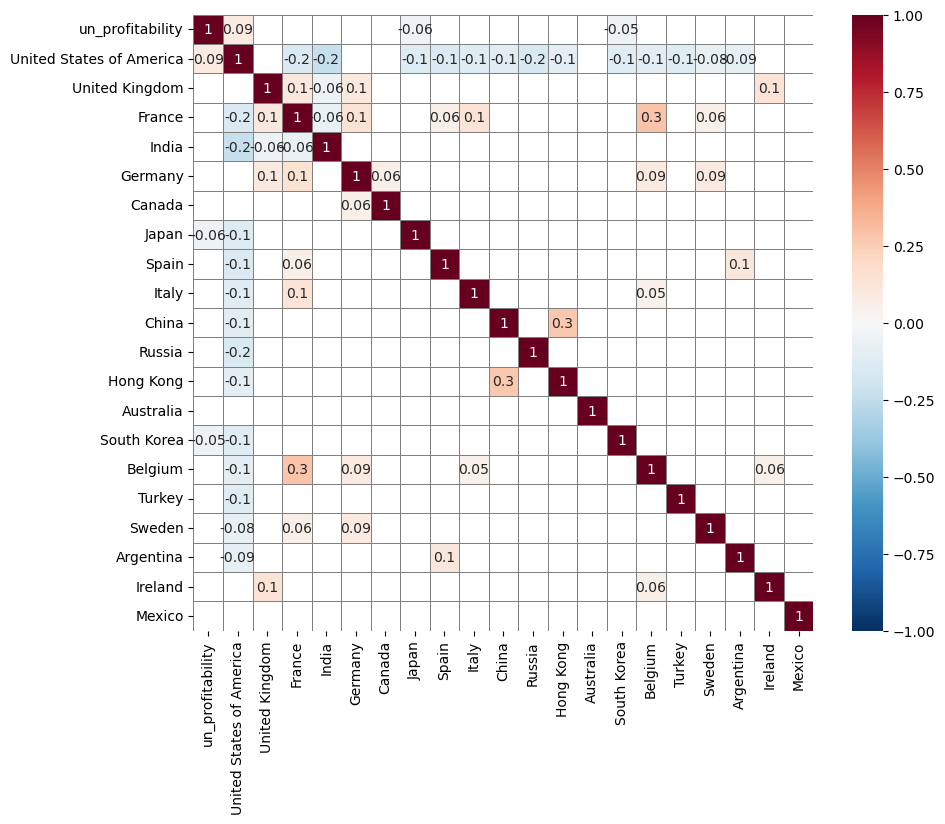

In [23]:
# Only takes the top 20 most common countries
added_countries = ["un_profitability"] + country_counts.head(20).index.tolist()
countries_correlation = df[added_countries].corr()

# Filtering out the correlations less than or equal to 0.05 to make the heatmap easier to read.
filter = 0.05
filtered_corr = countries_correlation[(countries_correlation > filter) | (countries_correlation < -filter)].dropna(how='all', axis=0).dropna(how='all', axis=1)

plt.figure(figsize=(10, 8))
sns.heatmap(
    filtered_corr,
    annot=True,
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    fmt=".1g", 
    linewidths=0.5, linecolor="grey")
plt.savefig("figures/heatmap of production country.png", bbox_inches = 'tight')
plt.show()

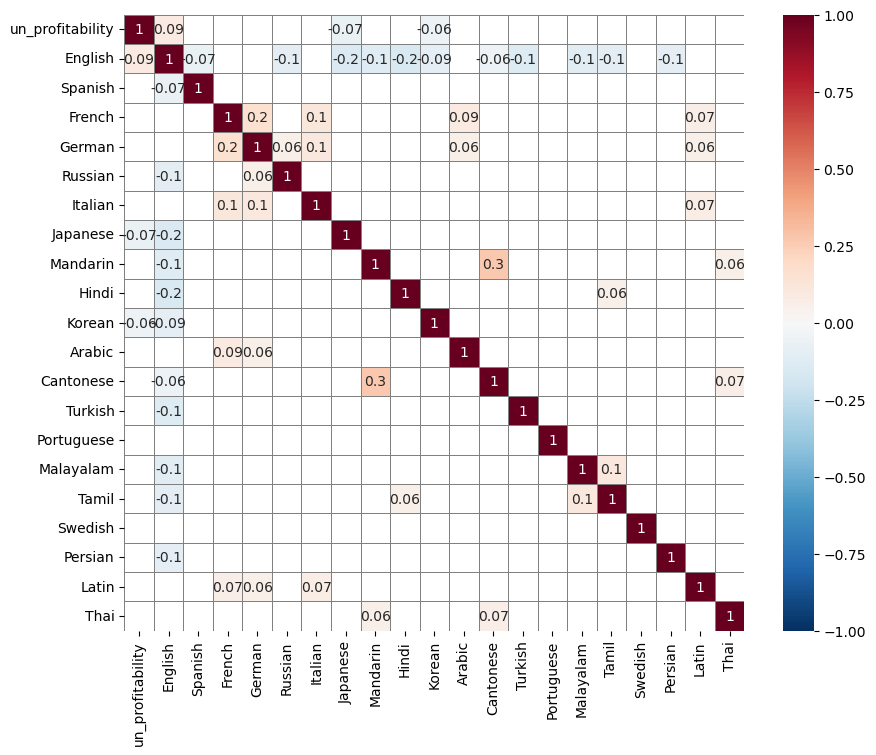

In [24]:
# only takes the top 20 common languages.
added_lang = ["un_profitability"] + language_counts.head(20).index.tolist()
lang_correlation = df[added_lang].corr()

# Filtering out the correlations less than or equal to 0.05 to make the heatmap easier to read.
filter = 0.05
filtered_corr = lang_correlation[(lang_correlation > filter) | (lang_correlation < -filter)].dropna(how='all', axis=0).dropna(how='all', axis=1)

plt.figure(figsize=(10, 8))
sns.heatmap(
    filtered_corr,
    annot=True,
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    fmt=".1g", 
    linewidths=0.5, linecolor="grey")
plt.savefig("figures/heatmap of spoken languages.png", bbox_inches = 'tight')
plt.show()

In [25]:
# Clean the data frame to eliminate low correlations.

# Keeping genres
# drop adult
# Changing original language to Orig_language_english
# Changing country to made_in_USA
# changing language to language_english

cleaned_df = df.copy()

print(cleaned_df.columns.tolist())

cleaned_df.drop(adult, axis=1, inplace=True)
cleaned_df.drop(genres, axis=1, inplace=True)

cleaned_df["original_language_english"] = cleaned_df["orig_lang_en"]
cleaned_df.drop(original_languages, axis=1, inplace=True)
cleaned_df["original_language_english"] = cleaned_df["original_language_english"].map({True: 1, False: 0})


cleaned_df["american_film"] = cleaned_df["United States of America"]
cleaned_df.drop(countries, axis=1, inplace=True)

cleaned_df["english_language"] = cleaned_df["English"]
cleaned_df.drop(languages, axis=1, inplace=True)

print(cleaned_df.columns.tolist())


['id', 'title', 'vote_average', 'vote_count', 'release_date', 'revenue', 'runtime', 'budget', 'popularity', 'actor_avg', 'actor_med', 'actor_dev', 'production_avg', 'production_med', 'production_dev', 'release_year', 'release_month', 'original_title_matches', 'adult_False', 'adult_True', 'orig_lang_ab', 'orig_lang_af', 'orig_lang_am', 'orig_lang_ar', 'orig_lang_az', 'orig_lang_be', 'orig_lang_bg', 'orig_lang_bm', 'orig_lang_bn', 'orig_lang_bs', 'orig_lang_ca', 'orig_lang_cn', 'orig_lang_cs', 'orig_lang_cy', 'orig_lang_da', 'orig_lang_de', 'orig_lang_dv', 'orig_lang_dz', 'orig_lang_el', 'orig_lang_en', 'orig_lang_es', 'orig_lang_et', 'orig_lang_eu', 'orig_lang_fa', 'orig_lang_fi', 'orig_lang_fr', 'orig_lang_ga', 'orig_lang_gl', 'orig_lang_gu', 'orig_lang_he', 'orig_lang_hi', 'orig_lang_hr', 'orig_lang_hu', 'orig_lang_hy', 'orig_lang_id', 'orig_lang_is', 'orig_lang_it', 'orig_lang_iu', 'orig_lang_ja', 'orig_lang_ka', 'orig_lang_km', 'orig_lang_kn', 'orig_lang_ko', 'orig_lang_ku', 'orig_l

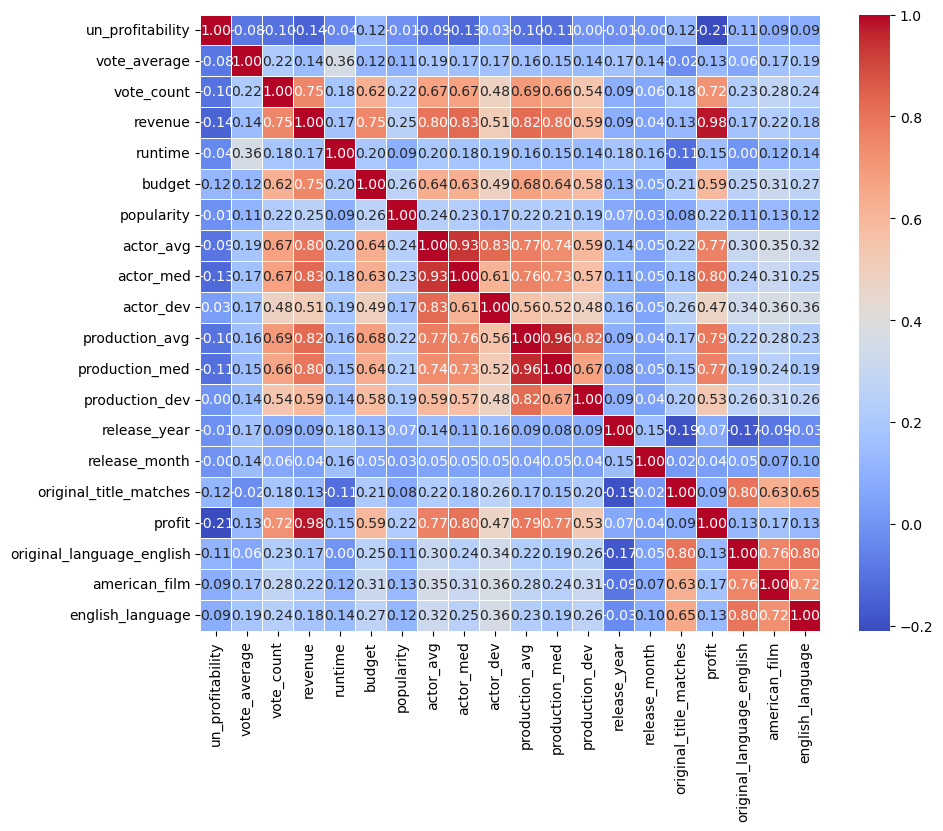

In [26]:
columns = ['un_profitability', 'vote_average', 'vote_count', 'revenue', 'runtime', 'budget', 'popularity', 'actor_avg', 'actor_med', 'actor_dev', 'production_avg', 'production_med', 'production_dev', 'release_year', 'release_month', 'original_title_matches', 'profit', 'original_language_english', 'american_film', 'english_language']

correlation = cleaned_df[columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.savefig("figures/heatmap of features (cool warm coloring).png", bbox_inches = 'tight')
plt.show()

In [27]:
# Fill in missing med, avg, dev for very small number of actor and production scores

# Fill missing actor statistics with lower quartile for avg and med, and median for dev
actor_avg_lower = cleaned_df['actor_avg'].quantile(0.25)
actor_med_lower = cleaned_df['actor_med'].quantile(0.25)
actor_dev_median = cleaned_df['actor_dev'].median()

cleaned_df['actor_avg'] = cleaned_df['actor_avg'].fillna(actor_avg_lower)
cleaned_df['actor_med'] = cleaned_df['actor_med'].fillna(actor_med_lower)
cleaned_df['actor_dev'] = cleaned_df['actor_dev'].fillna(actor_dev_median)

# Fill missing production statistics with lower quartile for avg and med, and median for dev
production_avg_lower = cleaned_df['production_avg'].quantile(0.25)
production_med_lower = cleaned_df['production_med'].quantile(0.25)
production_dev_median = cleaned_df['production_dev'].median()

cleaned_df['production_avg'] = cleaned_df['production_avg'].fillna(production_avg_lower)
cleaned_df['production_med'] = cleaned_df['production_med'].fillna(production_med_lower)
cleaned_df['production_dev'] = cleaned_df['production_dev'].fillna(production_dev_median)

print(cleaned_df[['actor_avg', 'actor_med', 'actor_dev', 'production_avg', 'production_med', 'production_dev']].head())


   actor_avg  actor_med  actor_dev  production_avg  production_med  \
0     338.47     246.27     238.15        1,054.56        1,034.78   
1     258.62     154.12     222.65          862.16        1,034.78   
2     267.93     191.81     210.53          773.34          836.51   
3     625.08     512.01     322.77        1,620.77        1,241.12   
4     883.51     865.99     283.03          750.20          566.35   

   production_dev  
0           39.56  
1          376.02  
2          328.17  
3          759.31  
4          629.10  


In [28]:
print(cleaned_df.columns)

Index(['id', 'title', 'vote_average', 'vote_count', 'release_date', 'revenue',
       'runtime', 'budget', 'popularity', 'actor_avg', 'actor_med',
       'actor_dev', 'production_avg', 'production_med', 'production_dev',
       'release_year', 'release_month', 'original_title_matches', 'profit',
       'un_profitability', 'original_language_english', 'american_film',
       'english_language'],
      dtype='object')


In [29]:
# Save to a csv.
cleaned_df.to_csv("movie-data/cleaned_analysis_data.csv", index=False)
print("cleaned_analysis_data.csv")


cleaned_analysis_data.csv


### Analysis work on baseline predictions:

In [30]:
df = cleaned_df.copy()

# Removing columns which aren't needed (or directly related to un-profitability).
df.drop(columns=["id", "title", "release_date", "profit", "revenue", "budget"], inplace=True)

Y_data = df["un_profitability"]
X_data = df.drop(columns=["un_profitability"])

In [31]:
X_train, X_test, Y_train, Y_test = train_test_split(X_data, Y_data, test_size=0.50, random_state=14)
print(f"X_train size: {X_train.shape}")
print(f"X_test size: {X_test.shape}")

# Finds which value is most common in the Y_train. So if 0s or 1s are more common.
majority_label = Y_train.mode()[0]
print(f"majority label: {majority_label}")

# Creates an array the same size as Y_test and sets every value to the majority label value.
Y_5050_prediction = np.full(shape=Y_test.shape, fill_value=majority_label)

confusion_matrix_5050 = confusion_matrix(Y_test, Y_5050_prediction)
print("Confusion Matrix: ")
print(confusion_matrix_5050)

print(classification_report(Y_test, Y_5050_prediction, zero_division=0))

# Display additional metrics: number of correct predictions out of total predictions
correct_predictions = (Y_test == Y_5050_prediction).sum()
total_predictions = len(Y_test)
print(f"Correctly predicted {correct_predictions} out of {total_predictions} instances")

X_train size: (8416, 16)
X_test size: (8416, 16)
majority label: 0
Confusion Matrix: 
[[5443    0]
 [2973    0]]
              precision    recall  f1-score   support

           0       0.65      1.00      0.79      5443
           1       0.00      0.00      0.00      2973

    accuracy                           0.65      8416
   macro avg       0.32      0.50      0.39      8416
weighted avg       0.42      0.65      0.51      8416

Correctly predicted 5443 out of 8416 instances


In [32]:
X_train, X_test, Y_train, Y_test = train_test_split(X_data, Y_data, test_size=0.20, random_state=14)
print(f"X_train size: {X_train.shape}")
print(f"X_test size: {X_test.shape}")

# Finds which value is most common in the Y_train. So if 0s or 1s are more common.
majority_label = Y_train.mode()[0]
print(f"majority label: {majority_label}")

# Creates an array the same size as Y_test and sets every value to the majority label value.
Y_8020_prediction = np.full(shape=Y_test.shape, fill_value=majority_label)

confusion_matrix_8020 = confusion_matrix(Y_test, Y_8020_prediction)
print("Confusion Matrix: ")
print(confusion_matrix_8020)

print(classification_report(Y_test, Y_8020_prediction, zero_division=0))

# Display additional metrics: number of correct predictions out of total predictions
correct_predictions = (Y_test == Y_8020_prediction).sum()
total_predictions = len(Y_test)
print(f"Correctly predicted {correct_predictions} out of {total_predictions} instances")

X_train size: (13465, 16)
X_test size: (3367, 16)
majority label: 0
Confusion Matrix: 
[[2144    0]
 [1223    0]]
              precision    recall  f1-score   support

           0       0.64      1.00      0.78      2144
           1       0.00      0.00      0.00      1223

    accuracy                           0.64      3367
   macro avg       0.32      0.50      0.39      3367
weighted avg       0.41      0.64      0.50      3367

Correctly predicted 2144 out of 3367 instances
